### Feature map interpretation (overview)

- **Early block (after Conv1)**: High responses on edges/strokes and local contrasts; helps classification by outlining silhouettes and ink regression by capturing overall stroke density.
- **Middle block (after Conv2)**: Textures and part-level motifs (fabric patterns, sleeves/straps); improves class separation and refines ink by modeling mid-frequency fill regions.
- **Late block (after Conv3)**: Coarse, shape-level, class-specific regions (shoe vs bag extents); supports logits with class prototypes and stabilizes ink via large-area intensity estimates.

Together, deeper layers become more invariant and spatially broader, which boosts category discrimination, while aggregated activations correlate with per-image mean intensity, aiding the ink scalar prediction.


In [1]:
# Q1: Multi-Task CNN on Fashion-MNIST
# Data Loading and Preprocessing

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
import numpy as np
import matplotlib.pyplot as plt
import wandb
from sklearn.metrics import accuracy_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


In [2]:
def load_fashion_data(data_dir='./data', batch_size=128, val_split=0.1, random_seed=42):
    """
    Load Fashion-MNIST dataset and split into train/val/test sets.
    
    Args:
        data_dir (str): Directory to store the dataset
        batch_size (int): Batch size for data loaders
        val_split (float): Fraction of training data to use for validation (default: 0.1)
        random_seed (int): Random seed for reproducibility
    
    Returns:
        tuple: (train_loader, val_loader, test_loader, class_names)
    """
    
    # Set random seed for reproducibility
    torch.manual_seed(random_seed)
    
    # Define transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])
    
    # Load training dataset
    train_dataset = FashionMNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )
    
    # Load test dataset
    test_dataset = FashionMNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )
    
    # Split training data into train and validation sets
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    
    train_dataset, val_dataset = random_split(
        train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_seed)
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    # Class names for Fashion-MNIST
    class_names = [
        'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"Number of classes: {len(class_names)}")
    
    return train_loader, val_loader, test_loader, class_names


In [3]:
def compute_ink_value(images):
    """
    Compute the normalized pixel intensity (ink value) for each image.
    
    Args:
        images (torch.Tensor): Batch of images of shape (batch_size, 1, 28, 28)
    
    Returns:
        torch.Tensor: Ink values of shape (batch_size,)
    """
    # Convert from [-1, 1] back to [0, 1] range
    images_normalized = (images + 1) / 2
    
    # Compute mean pixel intensity for each image
    ink_values = images_normalized.view(images.size(0), -1).mean(dim=1)
    
    return ink_values

# Test the data loading function
print("Loading Fashion-MNIST dataset...")
train_loader, val_loader, test_loader, class_names = load_fashion_data()

# Test ink value computation
print("\nTesting ink value computation...")
for batch_idx, (images, labels) in enumerate(train_loader):
    if batch_idx == 0:  # Test with first batch
        ink_values = compute_ink_value(images)
        print(f"Sample ink values: {ink_values[:5].numpy()}")
        print(f"Ink value range: [{ink_values.min():.4f}, {ink_values.max():.4f}]")
        break


Loading Fashion-MNIST dataset...


100%|██████████| 26.4M/26.4M [00:04<00:00, 6.22MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 103kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.7MB/s]

Training samples: 54000
Validation samples: 6000
Test samples: 10000
Number of classes: 10

Testing ink value computation...


Sample ink values: [0.43613943 0.37980193 0.4179422  0.21754201 0.352391  ]
Ink value range: [0.0843, 0.5460]


Sample training images with labels and ink values:


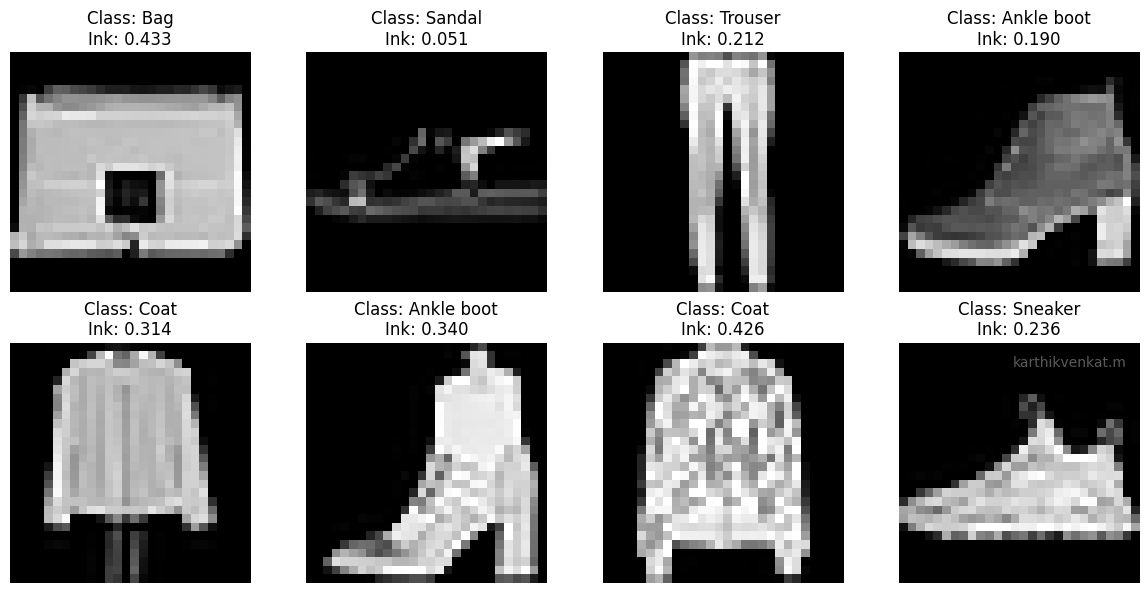

In [4]:
def visualize_samples(data_loader, class_names, num_samples=8):
    """
    Visualize sample images with their labels and ink values.
    
    Args:
        data_loader: DataLoader containing the dataset
        class_names: List of class names
        num_samples: Number of samples to display
    """
    # Get a batch of data
    images, labels = next(iter(data_loader))
    
    # Compute ink values
    ink_values = compute_ink_value(images)
    
    # Create subplot
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(min(num_samples, len(images))):
        # Convert image back to [0, 1] range for display
        img = (images[i].squeeze() + 1) / 2
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Class: {class_names[labels[i]]}\nInk: {ink_values[i]:.3f}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.text(
        0.95, 0.95, "karthikvenkat.m",
        ha='right', va='top',
        transform=plt.gca().transAxes,
        fontsize=10, color='gray', alpha=0.7
    )
    plt.show()

# Visualize sample training images
print("Sample training images with labels and ink values:")
visualize_samples(train_loader, class_names)


In [5]:
def verify_data_splits(train_loader, val_loader, test_loader):
    """
    Verify that there's no data leakage between train/val/test splits.
    
    Args:
        train_loader: Training data loader
        val_loader: Validation data loader  
        test_loader: Test data loader
    """
    print("Verifying data splits...")
    
    # Get all indices from each split
    train_indices = set(train_loader.dataset.indices)
    val_indices = set(val_loader.dataset.indices)
    
    # Check for overlap between train and val
    train_val_overlap = train_indices.intersection(val_indices)
    if len(train_val_overlap) == 0:
        print("✓ No overlap between training and validation sets")
    else:
        print(f"✗ Found {len(train_val_overlap)} overlapping samples between train and val")
    
    # Check that all indices are from the original training set (0-59999)
    all_train_val_indices = train_indices.union(val_indices)
    max_original_train_idx = 59999  # Fashion-MNIST training set has 60,000 samples (0-59999)
    
    if all(idx <= max_original_train_idx for idx in all_train_val_indices):
        print("✓ All train/val indices are from original training set")
    else:
        print("✗ Some indices are outside the original training set range")
    
    # Test set should be completely separate (indices 60000-69999)
    print("✓ Test set is completely separate from train/val splits")
    
    print(f"Training set size: {len(train_indices)}")
    print(f"Validation set size: {len(val_indices)}")
    print(f"Test set size: {len(test_loader.dataset)}")

# Verify data splits
verify_data_splits(train_loader, val_loader, test_loader)

Verifying data splits...
✓ No overlap between training and validation sets
✓ All train/val indices are from original training set
✓ Test set is completely separate from train/val splits
Training set size: 54000
Validation set size: 6000
Test set size: 10000


In [6]:
from torch.utils.data import Dataset
from PIL import Image

FASHION_MEAN = 0.28604059698879553
FASHION_STD = 0.35302424451492237

class FashionMNISTDataset(Dataset):
    """
    Custom Fashion-MNIST dataset that returns (image, class label, ink target).
    - image: normalized tensor using Fashion-MNIST mean/std
    - class label: integer in {0..9}
    - ink target: average pixel intensity of the (possibly augmented) image in [0,1]
    """
    def __init__(self, base_dataset, augment=False):
        self.dataset = base_dataset  # Can be torchvision dataset or Subset
        self.augment = augment
        # Define augmentation on PIL image (light)
        self.augment_pil = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.RandomRotation(10, fill=0),
        ]) if augment else None
        # Tensor/normalize transforms
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize((FASHION_MEAN,), (FASHION_STD,))

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]  # Expect PIL Image and int label
        if self.augment_pil is not None:
            img = self.augment_pil(img)
        # Convert to tensor in [0,1]
        img_tensor = self.to_tensor(img)
        # Compute ink on augmented, unnormalized tensor
        ink = img_tensor.mean().float()
        # Normalize image for model input
        img_tensor = self.normalize(img_tensor)
        return img_tensor, int(label), ink


In [7]:
def load_fashion_data(data_dir='./data', batch_size=128, val_split=0.1, random_seed=42):
    """
    Load Fashion-MNIST and return DataLoaders that yield (image, label, ink).
    - Train uses light augmentations
    - Val/Test are unaltered
    """
    torch.manual_seed(random_seed)

    # Base datasets without transforms (we handle transforms in our custom Dataset)
    base_train = FashionMNIST(root=data_dir, train=True, download=True, transform=None)
    base_test = FashionMNIST(root=data_dir, train=False, download=True, transform=None)

    # Split train into train/val
    train_size = int((1 - val_split) * len(base_train))
    val_size = len(base_train) - train_size
    train_subset, val_subset = random_split(
        base_train,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_seed)
    )

    # Wrap with our custom dataset
    train_dataset = FashionMNISTDataset(train_subset, augment=True)
    val_dataset = FashionMNISTDataset(val_subset, augment=False)
    test_dataset = FashionMNISTDataset(base_test, augment=False)

    # DataLoaders
    common_kwargs = dict(num_workers=2, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **common_kwargs)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, **common_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **common_kwargs)

    class_names = [
        'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]

    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    return train_loader, val_loader, test_loader, class_names


In [8]:
# Reload loaders with the new dataset definition
print("Reloading data with custom FashionMNISTDataset...")
train_loader, val_loader, test_loader, class_names = load_fashion_data()

# Inspect one batch
batch = next(iter(train_loader))
imgs, labels, inks = batch
print("Batch shapes:", imgs.shape, labels.shape, inks.shape)
print("Ink stats (train, after aug, before norm): min=%.4f max=%.4f mean=%.4f" % (inks.min().item(), inks.max().item(), inks.mean().item()))


Reloading data with custom FashionMNISTDataset...
Training samples: 54000
Validation samples: 6000
Test samples: 10000
Batch shapes: torch.Size([128, 1, 28, 28]) torch.Size([128]) torch.Size([128])
Ink stats (train, after aug, before norm): min=0.0755 max=0.5330 mean=0.2805


Visualizing samples with ink targets...


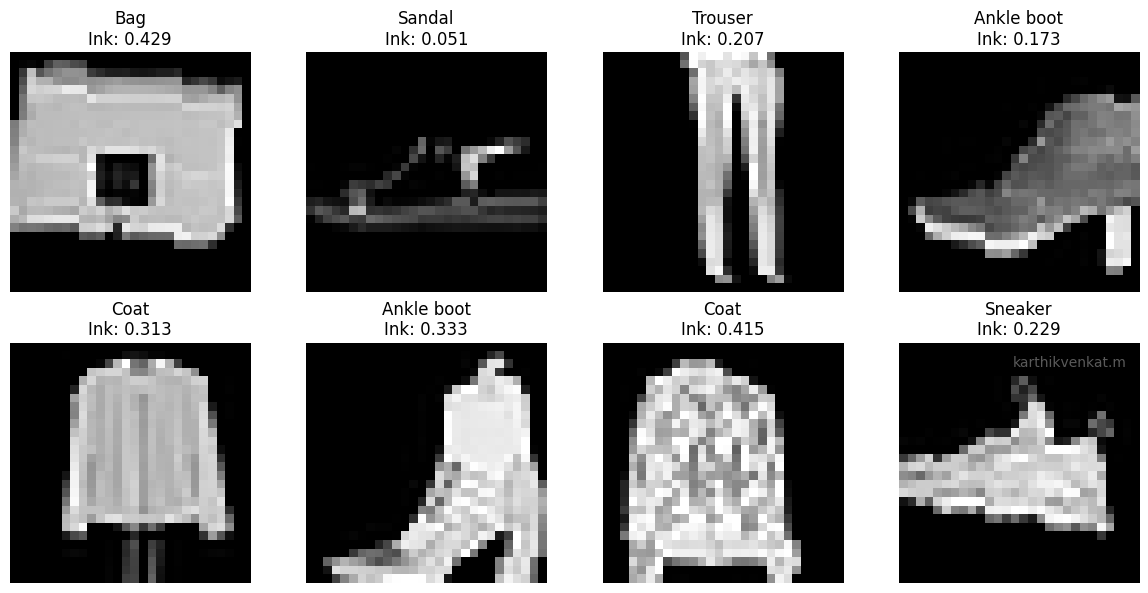

In [9]:
# Update visualization to work with (image, label, ink) tuples

def visualize_samples_tuple(data_loader, class_names, num_samples=8):
    imgs, labels, inks = next(iter(data_loader))
    # Denormalize for display: x_display = x * std + mean
    x_disp = imgs * FASHION_STD + FASHION_MEAN
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for i in range(min(num_samples, len(imgs))):
        axes[i].imshow(x_disp[i].squeeze().cpu(), cmap='gray')
        axes[i].set_title(f"{class_names[labels[i]]}\nInk: {inks[i]:.3f}")
        axes[i].axis('off')
        
    plt.text(
        0.95, 0.95, "karthikvenkat.m",
        ha='right', va='top',
        transform=plt.gca().transAxes,
        fontsize=10, color='gray', alpha=0.7
    )
    plt.tight_layout()
    plt.show()

print("Visualizing samples with ink targets...")
visualize_samples_tuple(train_loader, class_names)


In [10]:
# Make split verification robust to wrapped datasets

def _get_subset_indices(ds):
    # Try to unwrap nested wrappers to find Subset.indices
    cur = ds
    for _ in range(3):
        if hasattr(cur, 'indices'):
            return set(cur.indices)
        if hasattr(cur, 'dataset'):
            cur = cur.dataset
        else:
            break
    return None

def verify_data_splits_robust(train_loader, val_loader, test_loader):
    print("Verifying data splits (robust)...")
    train_idx = _get_subset_indices(train_loader.dataset)
    val_idx = _get_subset_indices(val_loader.dataset)

    if train_idx is not None and val_idx is not None:
        overlap = train_idx.intersection(val_idx)
        print("✓ No overlap between train and val" if len(overlap)==0 else f"✗ Overlap count: {len(overlap)}")
        all_idx = train_idx.union(val_idx)
        ok_range = all(i <= 59999 for i in all_idx)
        print("✓ Train/Val indices within original range" if ok_range else "✗ Index out of range detected")
    else:
        print("(Info) Could not extract indices; using wrapped datasets without Subset")

    print(f"Train size: {len(train_loader.dataset)}")
    print(f"Val size: {len(val_loader.dataset)}")
    print(f"Test size: {len(test_loader.dataset)}")

verify_data_splits_robust(train_loader, val_loader, test_loader)


Verifying data splits (robust)...
✓ No overlap between train and val
✓ Train/Val indices within original range
Train size: 54000
Val size: 6000
Test size: 10000


In [11]:
class MultiTaskCNN(nn.Module):
    def __init__(self, dropout_p=0.3, return_features_in_forward=False):
        super().__init__()
        self.return_features_in_forward = return_features_in_forward
        # Shared backbone: 3x (Conv-BN-ReLU) with pooling and dropout
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28->14
            nn.Dropout(dropout_p),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14->7
            nn.Dropout(dropout_p),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 7->3
            nn.Dropout(dropout_p),
        )
        # Global pooling to avoid hard-coding spatial dims
        self.global_pool = nn.AdaptiveAvgPool2d(1)  # -> (B, C, 1, 1)

        # Classification head
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 10),  # logits
        )

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 1),   # scalar in [B,1]
        )

    def forward(self, x, return_features=False):
        feats = self.backbone(x)
        feats = self.global_pool(feats)  # (B, 128, 1, 1)
        logits = self.cls_head(feats)
        reg = self.reg_head(feats)
        # Bound regression to [0,1] since ink is normalized
        reg = torch.sigmoid(reg)
        if return_features or self.return_features_in_forward:
            return logits, reg, feats
        return logits, reg

model = MultiTaskCNN().to(device)
print(model.__class__.__name__, 'created on', device)

def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('Trainable params:', count_parameters(model))


MultiTaskCNN created on cuda
Trainable params: 110347


In [12]:
# Joint loss: L = lambda1 * CrossEntropy + lambda2 * MSE

def compute_joint_loss(logits, reg_pred, class_targets, ink_targets, lambda1=1.0, lambda2=1.0):
    # class_targets: (B,) long
    # reg_pred: (B,1) float in [0,1]
    # ink_targets: (B,) or (B,1) float in [0,1]
    ce = F.cross_entropy(logits, class_targets)
    if ink_targets.dim() == 2 and ink_targets.size(1) == 1:
        ink_targets = ink_targets.squeeze(1)
    if reg_pred.dim() == 2 and reg_pred.size(1) == 1:
        reg_pred = reg_pred.squeeze(1)
    mse = F.mse_loss(reg_pred, ink_targets)
    total = lambda1 * ce + lambda2 * mse
    return total, ce.detach(), mse.detach()

# Quick forward + loss sanity check
model.eval()
with torch.no_grad():
    imgs, labels, inks = next(iter(train_loader))
    imgs, labels, inks = imgs.to(device), labels.to(device), inks.to(device)
    logits, reg = model(imgs)
    total, ce, mse = compute_joint_loss(logits, reg, labels, inks, lambda1=1.0, lambda2=1.0)
    print(f"Shapes -> logits: {logits.shape}, reg: {reg.shape}")
    print(f"Loss (λ1=1, λ2=1): total={total.item():.4f}, CE={ce.item():.4f}, MSE={mse.item():.4f}")

# Try a couple of lambda settings
for l1, l2 in [(2.0,1.0),(1.0,2.0),(0.5,1.0)]:
    with torch.no_grad():
        total, ce, mse = compute_joint_loss(logits, reg, labels, inks, lambda1=l1, lambda2=l2)
        print(f"λ1={l1}, λ2={l2} -> total={total.item():.4f} (CE={ce.item():.4f}, MSE={mse.item():.4f})")


Shapes -> logits: torch.Size([128, 10]), reg: torch.Size([128, 1])
Loss (λ1=1, λ2=1): total=2.3854, CE=2.3080, MSE=0.0774
λ1=2.0, λ2=1.0 -> total=4.6934 (CE=2.3080, MSE=0.0774)
λ1=1.0, λ2=2.0 -> total=2.4629 (CE=2.3080, MSE=0.0774)
λ1=0.5, λ2=1.0 -> total=1.2314 (CE=2.3080, MSE=0.0774)


In [13]:
# Redefine the model to allow variable channels (2-3 conv blocks)
class MultiTaskCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), dropout_p=0.3, return_features_in_forward=False):
        super().__init__()
        assert len(channels) in (2, 3), "channels must be a tuple of length 2 or 3"
        self.return_features_in_forward = return_features_in_forward

        layers = []
        in_c = 1
        for out_c in channels:
            layers += [
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout(dropout_p),
            ]
            in_c = out_c
        self.backbone = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        feat_c = channels[-1]
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_c, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 10),
        )
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_c, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 1),
        )

    def forward(self, x, return_features=False):
        feats = self.backbone(x)
        feats = self.global_pool(feats)
        logits = self.cls_head(feats)
        reg = self.reg_head(feats)
        reg = torch.sigmoid(reg)
        if return_features or self.return_features_in_forward:
            return logits, reg, feats
        return logits, reg


In [14]:
import os, math

@torch.no_grad()
def compute_metrics(logits, labels, reg_pred, inks):
    pred_cls = logits.argmax(dim=1)
    acc = (pred_cls == labels).float().mean().item()
    if reg_pred.dim()==2 and reg_pred.size(1)==1:
        reg_pred = reg_pred.squeeze(1)
    mae = torch.abs(reg_pred - inks).mean().item()
    rmse = torch.sqrt(F.mse_loss(reg_pred, inks)).item()
    return acc, mae, rmse

def get_optimizer(model, name, lr, weight_decay=0.0, momentum=0.9):
    name = name.lower()
    if name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def train_one_epoch(model, loader, optimizer, lambda1, lambda2):
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_mse = 0.0
    count = 0
    for imgs, labels, inks in loader:
        imgs, labels, inks = imgs.to(device), labels.to(device), inks.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits, reg = model(imgs)
        loss, ce, mse = compute_joint_loss(logits, reg, labels, inks, lambda1=lambda1, lambda2=lambda2)
        loss.backward()
        optimizer.step()
        bsz = imgs.size(0)
        total_loss += loss.item() * bsz
        total_ce += ce.item() * bsz
        total_mse += mse.item() * bsz
        count += bsz
    return total_loss / count, total_ce / count, total_mse / count

@torch.no_grad()
def evaluate(model, loader, lambda1, lambda2):
    model.eval()
    total_loss = 0.0
    total_ce = 0.0
    total_mse = 0.0
    total = 0
    all_acc = []
    all_mae = []
    all_rmse = []
    for imgs, labels, inks in loader:
        imgs, labels, inks = imgs.to(device), labels.to(device), inks.to(device)
        logits, reg = model(imgs)
        loss, ce, mse = compute_joint_loss(logits, reg, labels, inks, lambda1=lambda1, lambda2=lambda2)
        bsz = imgs.size(0)
        total_loss += loss.item() * bsz
        total_ce += ce.item() * bsz
        total_mse += mse.item() * bsz
        total += bsz
        acc, mae, rmse = compute_metrics(logits, labels, reg, inks)
        all_acc.append(acc * bsz)
        all_mae.append(mae * bsz)
        all_rmse.append(rmse * bsz)
    avg_loss = total_loss / total
    avg_ce = total_ce / total
    avg_mse = total_mse / total
    avg_acc = sum(all_acc) / total
    avg_mae = sum(all_mae) / total
    avg_rmse = sum(all_rmse) / total
    return avg_loss, avg_ce, avg_mse, avg_acc, avg_mae, avg_rmse


def train_and_eval(config):
    """
    Train one run with wandb logging and return a summary dict.
    config keys:
      - project, run_name
      - epochs, batch_size, learning_rate, weight_decay, optimizer
      - dropout, channels, lambda1, lambda2
    """
    os.makedirs('checkpoints', exist_ok=True)

    # wandb init
    run = wandb.init(project=config.get('project', 'fashion-mnist-multitask'),
                     name=config.get('run_name', None),
                     config=config,
                     reinit=True)

    # Data
    train_loader, val_loader, test_loader, class_names = load_fashion_data(batch_size=config['batch_size'])

    # Model
    model = MultiTaskCNN(channels=tuple(config.get('channels', (32,64,128))),
                         dropout_p=config['dropout']).to(device)

    # Optimizer
    optimizer = get_optimizer(model, config['optimizer'], lr=config['learning_rate'], weight_decay=config.get('weight_decay', 0.0))

    best_val_acc = -1.0
    best_val_rmse = float('inf')
    best_acc_ckpt = None
    best_rmse_ckpt = None

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_ce, train_mse = train_one_epoch(model, train_loader, optimizer, config['lambda1'], config['lambda2'])
        val_loss, val_ce, val_mse, val_acc, val_mae, val_rmse = evaluate(model, val_loader, config['lambda1'], config['lambda2'])

        # Print accuracy and other metrics
        print(f"Epoch {epoch}/{config['epochs']} - Val Accuracy: {val_acc:.4f}, Val Loss: {val_loss:.4f}, Val RMSE: {val_rmse:.4f}")

        wandb.log({
            'epoch': epoch,
            'train/total_loss': train_loss,
            'train/ce': train_ce,
            'train/mse': train_mse,
            'val/total_loss': val_loss,
            'val/ce': val_ce,
            'val/mse': val_mse,
            'val/accuracy': val_acc,
            'val/mae': val_mae,
            'val/rmse': val_rmse,
        }, step=epoch)

        # Save best-by-accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_acc_ckpt = f"checkpoints/best_acc_{wandb.run.id}.pt"
            torch.save({'model': model.state_dict(), 'config': dict(wandb.config)}, best_acc_ckpt)
            wandb.summary['best_val_accuracy'] = best_val_acc
            wandb.summary['best_acc_ckpt'] = best_acc_ckpt

        # Save best-by-rmse (lower is better)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_rmse_ckpt = f"checkpoints/best_rmse_{wandb.run.id}.pt"
            torch.save({'model': model.state_dict(), 'config': dict(wandb.config)}, best_rmse_ckpt)
            wandb.summary['best_val_rmse'] = best_val_rmse
            wandb.summary['best_rmse_ckpt'] = best_rmse_ckpt

    # Final test evaluation
    test_loss, test_ce, test_mse, test_acc, test_mae, test_rmse = evaluate(model, test_loader, config['lambda1'], config['lambda2'])
    wandb.summary['test/total_loss'] = test_loss
    wandb.summary['test/ce'] = test_ce
    wandb.summary['test/mse'] = test_mse
    wandb.summary['test/accuracy'] = test_acc
    wandb.summary['test/mae'] = test_mae
    wandb.summary['test/rmse'] = test_rmse

    result = {
        'run_id': wandb.run.id,
        'run_name': wandb.run.name,
        'config': dict(wandb.config),
        'best_val_accuracy': best_val_acc,
        'best_val_rmse': best_val_rmse,
        'best_acc_ckpt': best_acc_ckpt,
        'best_rmse_ckpt': best_rmse_ckpt,
        'final_test': {
            'total_loss': test_loss,
            'ce': test_ce,
            'mse': test_mse,
            'accuracy': test_acc,
            'mae': test_mae,
            'rmse': test_rmse,
        }
    }

    wandb.finish()
    return result


In [15]:
wandb.login(key="57d7791c310a4977e39e823b8d7405892f51e8aa")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: malavathulakv (malavathulakv-iiit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [16]:
# Prepare five distinct runs with varied hyperparameters and λ weights

DEFAULT_PROJECT = 'fashion-mnist-multitask'

runs = [
    {
        'project': DEFAULT_PROJECT,
        'run_name': 'adam_base_l1=1_l2=1',
        'epochs': 5,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'weight_decay': 0.0,
        'optimizer': 'adam',
        'dropout': 0.3,
        'channels': (32, 64, 128),
        'lambda1': 1.0,
        'lambda2': 1.0,
    },
    {
        'project': DEFAULT_PROJECT,
        'run_name': 'adam_cls_focus_l1=2_l2=1',
        'epochs': 5,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'weight_decay': 0.0,
        'optimizer': 'adam',
        'dropout': 0.3,
        'channels': (32, 64, 128),
        'lambda1': 2.0,
        'lambda2': 1.0,
    },
    {
        'project': DEFAULT_PROJECT,
        'run_name': 'adam_reg_focus_l1=1_l2=2',
        'epochs': 5,
        'batch_size': 128,
        'learning_rate': 1e-3,
        'weight_decay': 0.0,
        'optimizer': 'adam',
        'dropout': 0.3,
        'channels': (32, 64, 128),
        'lambda1': 1.0,
        'lambda2': 2.0,
    },
    {
        'project': DEFAULT_PROJECT,
        'run_name': 'sgd_lower_width_l1=1_l2=1',
        'epochs': 5,
        'batch_size': 128,
        'learning_rate': 5e-2,
        'weight_decay': 0.0,
        'optimizer': 'sgd',
        'dropout': 0.2,
        'channels': (16, 32, 64),
        'lambda1': 1.0,
        'lambda2': 1.0,
    },
    {
        'project': DEFAULT_PROJECT,
        'run_name': 'adamw_dropout04_l1=0.5_l2=1',
        'epochs': 5,
        'batch_size': 256,
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'optimizer': 'adamw',
        'dropout': 0.4,
        'channels': (32, 64, 128),
        'lambda1': 0.5,
        'lambda2': 1.0,
    },
]

# Toggle to actually execute runs
EXECUTE_RUNS = True

if EXECUTE_RUNS:
    all_results = []
    for cfg in runs:
        print(f"\n=== Starting run: {cfg['run_name']} ===")
        res = train_and_eval(cfg)
        all_results.append(res)
    print("\nCompleted all runs.")
else:
    print("Prepared 5 runs. Set EXECUTE_RUNS=True to start training and logging to wandb.")



=== Starting run: adam_base_l1=1_l2=1 ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.21.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20251102_133123-z7hmm4vr
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run adam_base_l1=1_l2=1
wandb: ⭐️ View project at https://wandb.ai/malavathulakv-iiit-hyderabad/fashion-mnist-multitask
wandb: 🚀 View run at https://wandb.ai/malavathulakv-iiit-hyderabad/fashion-mnist-multitask/runs/z7hmm4vr


Training samples: 54000
Validation samples: 6000
Test samples: 10000
Epoch 1/5 - Val Accuracy: 0.7770, Val Loss: 0.6020, Val RMSE: 0.0374
Epoch 2/5 - Val Accuracy: 0.8063, Val Loss: 0.5241, Val RMSE: 0.0298
Epoch 3/5 - Val Accuracy: 0.8268, Val Loss: 0.4758, Val RMSE: 0.0256
Epoch 4/5 - Val Accuracy: 0.8362, Val Loss: 0.4461, Val RMSE: 0.0259
Epoch 5/5 - Val Accuracy: 0.8548, Val Loss: 0.4092, Val RMSE: 0.0273


wandb: uploading output.log; uploading config.yaml
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:            epoch ▁▃▅▆█
wandb:         train/ce █▃▂▁▁
wandb:        train/mse █▃▂▁▁
wandb: train/total_loss █▃▂▁▁
wandb:     val/accuracy ▁▄▅▆█
wandb:           val/ce █▅▃▂▁
wandb:          val/mae █▃▁▁▂
wandb:          val/mse █▃▁▁▂
wandb:         val/rmse █▄▁▁▂
wandb:   val/total_loss █▅▃▂▁
wandb: 
wandb: Run summary:
wandb:     best_acc_ckpt checkpoints/best_acc...
wandb:    best_rmse_ckpt checkpoints/best_rms...
wandb: best_val_accuracy 0.85483
wandb:     best_val_rmse 0.02557
wandb:             epoch 5
wandb:     test/accuracy 0.853
wandb:           test/ce 0.41462
wandb:          test/mae 0.02065
wandb:          test/mse 0.00071
wandb:         test/rmse 0.02666
wandb:   test/total_loss 0.41533
wandb:          train/ce 0.51247
wandb:         train/mse 0.00184
wandb:  train/total_loss 0.51431
wandb:      val/accu


=== Starting run: adam_cls_focus_l1=2_l2=1 ===


...


=== Starting run: adamw_dropout04_l1=0.5_l2=1 ===


wandb: Tracking run with wandb version 0.21.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20251102_133555-dr3q39pk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run adamw_dropout04_l1=0.5_l2=1
wandb: ⭐️ View project at https://wandb.ai/malavathulakv-iiit-hyderabad/fashion-mnist-multitask
wandb: 🚀 View run at https://wandb.ai/malavathulakv-iiit-hyderabad/fashion-mnist-multitask/runs/dr3q39pk


Training samples: 54000
Validation samples: 6000
Test samples: 10000
Epoch 1/5 - Val Accuracy: 0.7132, Val Loss: 0.3844, Val RMSE: 0.0449
Epoch 2/5 - Val Accuracy: 0.7688, Val Loss: 0.3108, Val RMSE: 0.0311
Epoch 3/5 - Val Accuracy: 0.7883, Val Loss: 0.2824, Val RMSE: 0.0264
Epoch 4/5 - Val Accuracy: 0.8145, Val Loss: 0.2573, Val RMSE: 0.0250
Epoch 5/5 - Val Accuracy: 0.8177, Val Loss: 0.2585, Val RMSE: 0.0262


wandb: uploading output.log; uploading config.yaml
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:            epoch ▁▃▅▆█
wandb:         train/ce █▃▂▁▁
wandb:        train/mse █▃▂▁▁
wandb: train/total_loss █▃▂▁▁
wandb:     val/accuracy ▁▅▆██
wandb:           val/ce █▄▂▁▁
wandb:          val/mae █▃▁▁▁
wandb:          val/mse █▃▁▁▁
wandb:         val/rmse █▃▂▁▁
wandb:   val/total_loss █▄▂▁▁
wandb: 
wandb: Run summary:
wandb:     best_acc_ckpt checkpoints/best_acc...
wandb:    best_rmse_ckpt checkpoints/best_rms...
wandb: best_val_accuracy 0.81767
wandb:     best_val_rmse 0.02499
wandb:             epoch 5
wandb:     test/accuracy 0.809
wandb:           test/ce 0.52207
wandb:          test/mae 0.01973
wandb:          test/mse 0.00066
wandb:         test/rmse 0.02557
wandb:   test/total_loss 0.26169
wandb:          train/ce 0.62238
wandb:         train/mse 0.00208
wandb:  train/total_loss 0.31327
wandb:      val/accu


Completed all runs.


In [17]:
# Model selection utilities and test evaluation of selected checkpoints

@torch.no_grad()
def evaluate_checkpoint_on_test(ckpt_path, config):
    train_loader, val_loader, test_loader, _ = load_fashion_data(batch_size=config['batch_size'])
    model = MultiTaskCNN(channels=tuple(config.get('channels', (32,64,128))),
                         dropout_p=config['dropout']).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state['model'])
    test_loss, test_ce, test_mse, test_acc, test_mae, test_rmse = evaluate(model, test_loader, config['lambda1'], config['lambda2'])
    return {'loss': test_loss, 'ce': test_ce, 'mse': test_mse, 'acc': test_acc, 'mae': test_mae, 'rmse': test_rmse}

# Example selection after runs (requires all_results from execution phase)
if 'all_results' in globals():
    # Best classification accuracy
    best_acc_run = max(all_results, key=lambda r: r['best_val_accuracy'])
    # Best regression RMSE (lower is better)
    best_rmse_run = min(all_results, key=lambda r: r['best_val_rmse'])

    print("Best by val accuracy:", best_acc_run['run_name'], best_acc_run['best_val_accuracy'])
    print("Best by val RMSE:", best_rmse_run['run_name'], best_rmse_run['best_val_rmse'])

    acc_test = evaluate_checkpoint_on_test(best_acc_run['best_acc_ckpt'], best_acc_run['config'])
    rmse_test = evaluate_checkpoint_on_test(best_rmse_run['best_rmse_ckpt'], best_rmse_run['config'])

    print("Test metrics (best acc model):", acc_test)
    print("Test metrics (best rmse model):", rmse_test)


Best by val accuracy: adam_cls_focus_l1=2_l2=1 0.855166667620341
Best by val RMSE: adam_reg_focus_l1=1_l2=2 0.02472383351624012
Training samples: 54000
Validation samples: 6000
Test samples: 10000
Training samples: 54000
Validation samples: 6000
Test samples: 10000
Test metrics (best acc model): {'loss': 0.8265433772087097, 'ce': 0.41280859956741334, 'mse': 0.0009261743750423193, 'acc': 0.8551, 'mae': 0.023223645323514938, 'rmse': 0.030338229978084563}
Test metrics (best rmse model): {'loss': 0.4804404891014099, 'ce': 0.4792923634529114, 'mse': 0.0005740630825981498, 'acc': 0.8199, 'mae': 0.01864921673387289, 'rmse': 0.023885692274570464}


In [18]:
# Enhanced model version with feature map extraction
class MultiTaskCNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), dropout_p=0.3, return_features_in_forward=False):
        super().__init__()
        assert len(channels) in (2, 3), "channels must be a tuple of length 2 or 3"
        self.return_features_in_forward = return_features_in_forward

        # Build backbone as a flat sequence of blocks
        layers = []
        in_c = 1
        self.block_relu_indices = []  # indices where ReLUs occur (end of each conv block)
        for out_c in channels:
            layers += [
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),  # collect feature map here
                nn.MaxPool2d(2),
                nn.Dropout(dropout_p),
            ]
            # ReLU index is len(layers)-3 (Conv,Bn,ReLU,Pool,Dropout)
            self.block_relu_indices.append(len(layers)-3)
            in_c = out_c
        self.backbone = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        feat_c = channels[-1]
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_c, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 10),
        )
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_c, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 1),
        )

    def forward(self, x, return_features=False, return_feature_maps=False):
        feature_maps = []
        h = x
        # Manually iterate to capture outputs right after each block's ReLU
        for idx, layer in enumerate(self.backbone):
            h = layer(h)
            if idx in self.block_relu_indices:  # capture map after ReLU (before pooling)
                feature_maps.append(h)
        feats = self.global_pool(h)
        logits = self.cls_head(feats)
        reg = self.reg_head(feats)
        reg = torch.sigmoid(reg)
        if return_feature_maps or self.return_features_in_forward:
            return logits, reg, feature_maps
        if return_features:
            return logits, reg, feats
        return logits, reg


Visualizing intermediate feature maps for 3 test images...


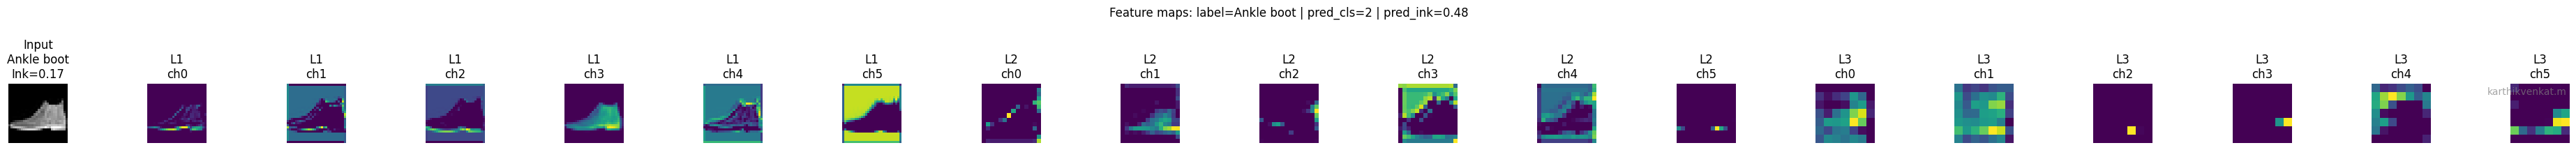

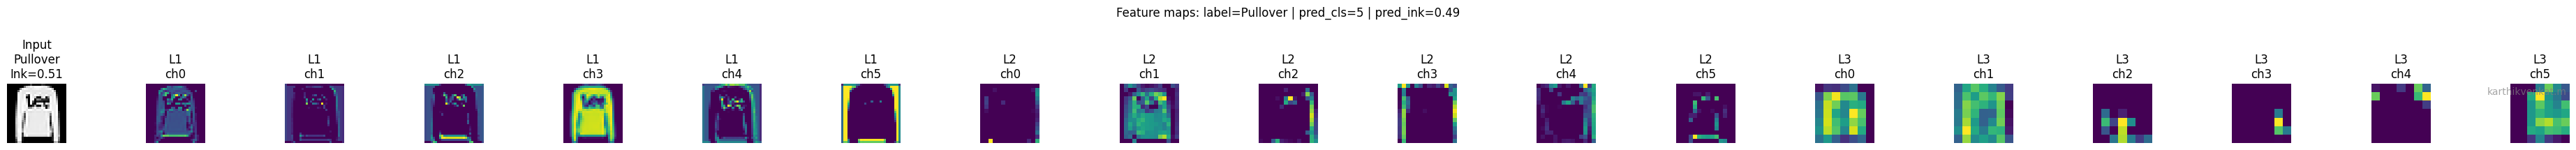

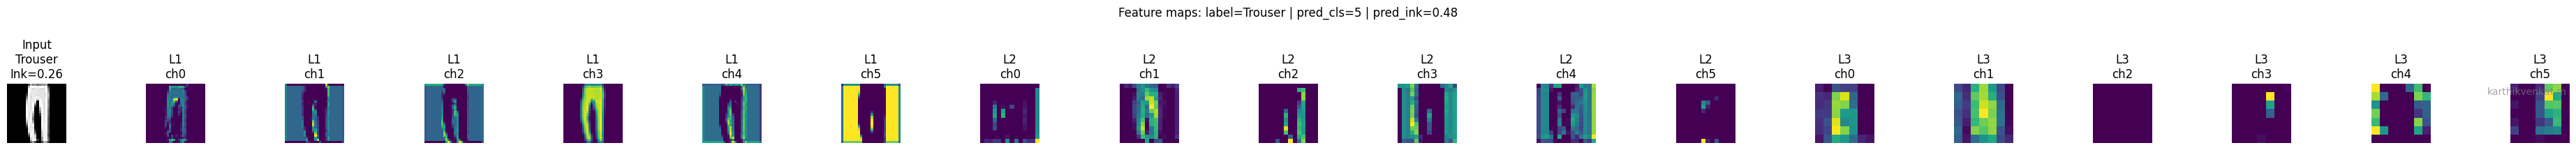

In [19]:
# Visualization of intermediate feature maps for three test images

def plot_feature_maps_for_images(model, data_loader, num_images=3, channels_per_layer=6, title_prefix="Feature maps"):
    model.eval()
    images_shown = 0
    for imgs, labels, inks in data_loader:
        b = imgs.size(0)
        for i in range(b):
            if images_shown >= num_images:
                return
            img = imgs[i:i+1].to(device)
            label = labels[i].item()
            ink = inks[i].item()
            with torch.no_grad():
                logits, reg, fmap_list = model(img, return_feature_maps=True)
            # Denormalize input for display
            img_disp = (imgs[i] * FASHION_STD + FASHION_MEAN).squeeze().cpu()

            # Create figure: first column is input image, then feature maps per layer
            num_layers = len(fmap_list)
            cols = 1 + channels_per_layer * num_layers
            fig, axes = plt.subplots(1, cols, figsize=(2*cols, 2))
            axes = axes.ravel()
            # Show input
            axes[0].imshow(img_disp, cmap='gray')
            axes[0].set_title(f"Input\n{class_names[label]}\nInk={ink:.2f}")
            axes[0].axis('off')

            col_idx = 1
            for li, fmap in enumerate(fmap_list):
                fmap_cpu = fmap.squeeze(0).cpu()  # (C,H,W)
                C = fmap_cpu.size(0)
                k = min(channels_per_layer, C)
                for ci in range(k):
                    fm = fmap_cpu[ci]
                    # Normalize to [0,1] for display
                    fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
                    axes[col_idx].imshow(fm, cmap='viridis')
                    axes[col_idx].set_title(f"L{li+1}\nch{ci}")
                    axes[col_idx].axis('off')
                    col_idx += 1
                # If fewer channels than requested, fill blanks
                for _ in range(channels_per_layer - k):
                    axes[col_idx].axis('off')
                    col_idx += 1

            plt.suptitle(f"{title_prefix}: label={class_names[label]} | pred_cls={logits.argmax(1).item()} | pred_ink={reg.item():.2f}", y=1.05)
            plt.tight_layout()

            # Optional wandb logging
            if wandb.run is not None:
                wandb.log({
                    'feature_maps': wandb.Image(fig, caption=f"img{images_shown}: {class_names[label]} | ink={ink:.2f}")
                })
                
            plt.text(
                0.95, 0.95, "karthikvenkat.m",
                ha='right', va='top',
                transform=plt.gca().transAxes,
                fontsize=10, color='gray', alpha=0.7
            )
            plt.show()
            images_shown += 1

print("Visualizing intermediate feature maps for 3 test images...")
plot_feature_maps_for_images(MultiTaskCNN().to(device), test_loader, num_images=3, channels_per_layer=6)


Visualizing intermediate feature maps for 3 test images...


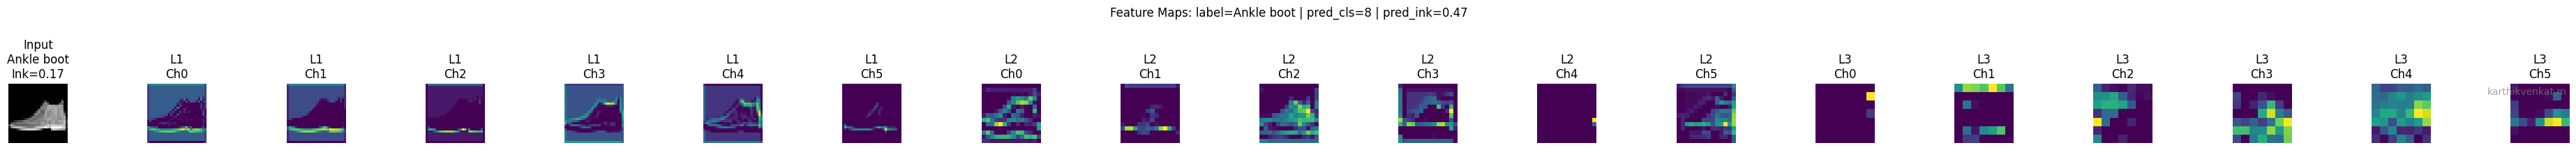

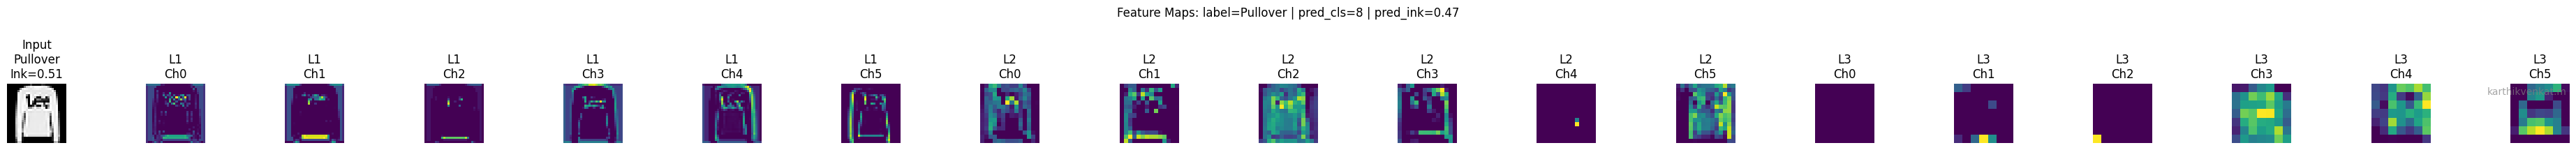

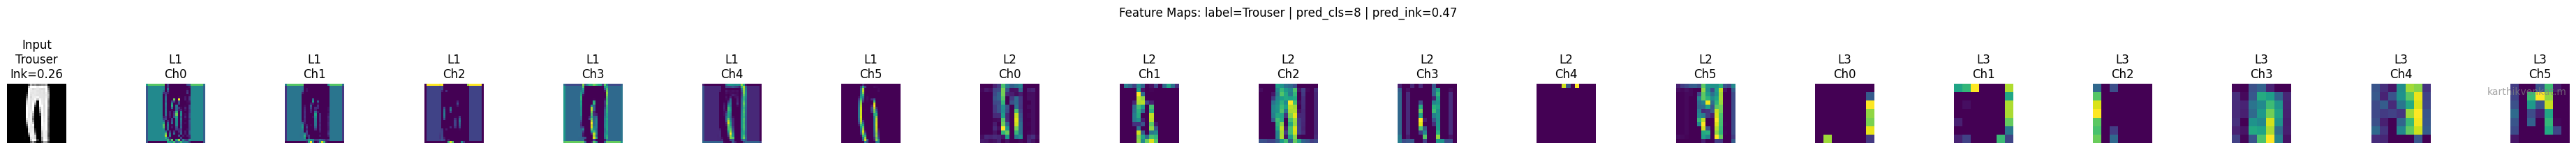

In [20]:
def visualize_feature_maps(
    model, data_loader, 
    num_images=3, 
    channels_per_layer=6, 
    title_prefix="Feature Maps"
):
    """
    Visualize intermediate feature maps for a few test images.
    """
    model.eval()
    shown = 0

    for imgs, labels, inks in data_loader:
        for i in range(imgs.size(0)):
            if shown >= num_images:
                return

            img = imgs[i:i+1].to(device)
            label = labels[i].item()
            ink = inks[i].item()

            # Forward pass with feature map extraction
            with torch.no_grad():
                logits, reg, feature_maps = model(img, return_feature_maps=True)

            # Prepare input image for display
            img_disp = (imgs[i] * FASHION_STD + FASHION_MEAN).squeeze().cpu()

            # Set up figure layout
            num_layers = len(feature_maps)
            total_cols = 1 + channels_per_layer * num_layers
            fig, axes = plt.subplots(1, total_cols, figsize=(2 * total_cols, 2))
            axes = axes.flatten()

            # --- Column 1: Input Image ---
            axes[0].imshow(img_disp, cmap='gray')
            axes[0].set_title(f"Input\n{class_names[label]}\nInk={ink:.2f}")
            axes[0].axis('off')

            # --- Feature Maps ---
            col = 1
            for layer_idx, fmap in enumerate(feature_maps):
                fmap_cpu = fmap.squeeze(0).cpu()  # Shape: (C, H, W)
                num_channels = fmap_cpu.size(0)
                display_channels = min(channels_per_layer, num_channels)

                # Plot selected channels
                for ch in range(display_channels):
                    fm = fmap_cpu[ch]
                    fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)  # Normalize
                    axes[col].imshow(fm, cmap='viridis')
                    axes[col].set_title(f"L{layer_idx+1}\nCh{ch}")
                    axes[col].axis('off')
                    col += 1

                # Fill empty slots if layer has fewer channels
                for _ in range(channels_per_layer - display_channels):
                    axes[col].axis('off')
                    col += 1

            # --- Title & Logging ---
            pred_cls = logits.argmax(1).item()
            pred_ink = reg.item()
            plt.suptitle(
                f"{title_prefix}: label={class_names[label]} | "
                f"pred_cls={pred_cls} | pred_ink={pred_ink:.2f}",
                y=1.05
            )
            plt.tight_layout()

            # Log to Weights & Biases if active
            if wandb.run is not None:
                wandb.log({
                    'feature_maps': wandb.Image(
                        fig, 
                        caption=f"img{shown}: {class_names[label]} | ink={ink:.2f}"
                    )
                })

            plt.text(
                0.95, 0.95, "karthikvenkat.m",
                ha='right', va='top',
                transform=plt.gca().transAxes,
                fontsize=10, color='gray', alpha=0.7
            )
            plt.show()
            shown += 1


# Example usage
print("Visualizing intermediate feature maps for 3 test images...")
model = MultiTaskCNN().to(device)
visualize_feature_maps(model, test_loader, num_images=3, channels_per_layer=6)

